# Plot Zero-Variance extrapolation - 1D chain L = 20

In [26]:
import glob
import os
import sys

In [27]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.plot.plotlib import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
verbose = True

In [29]:
# Settings
L = 20                                              # Length of the Markov chain
N_sim = 1000000                                     # Number of Monte Carlo simulations

## Alpha optimization

In [30]:
dossiers = glob.glob("../../datas/2D_4x4/datas_alpha_iter_*") 

Loading and processing 2 folders...
✅ Loading complete: 2 simulations processed!
Generating 1000000 synthetic linear regressions...

========== GLOBAL MONTE CARLO RESULTS ==========
Points used for fit       : 4 (2 simulations)
Exact Energy              : -0.56142416
Extrapolated Energy       : -0.56098740 ± 0.00053361
95% Confidence Interval   : [-0.56211183 , -0.55999460]
Absolute Error vs Exact   : 4.37e-04


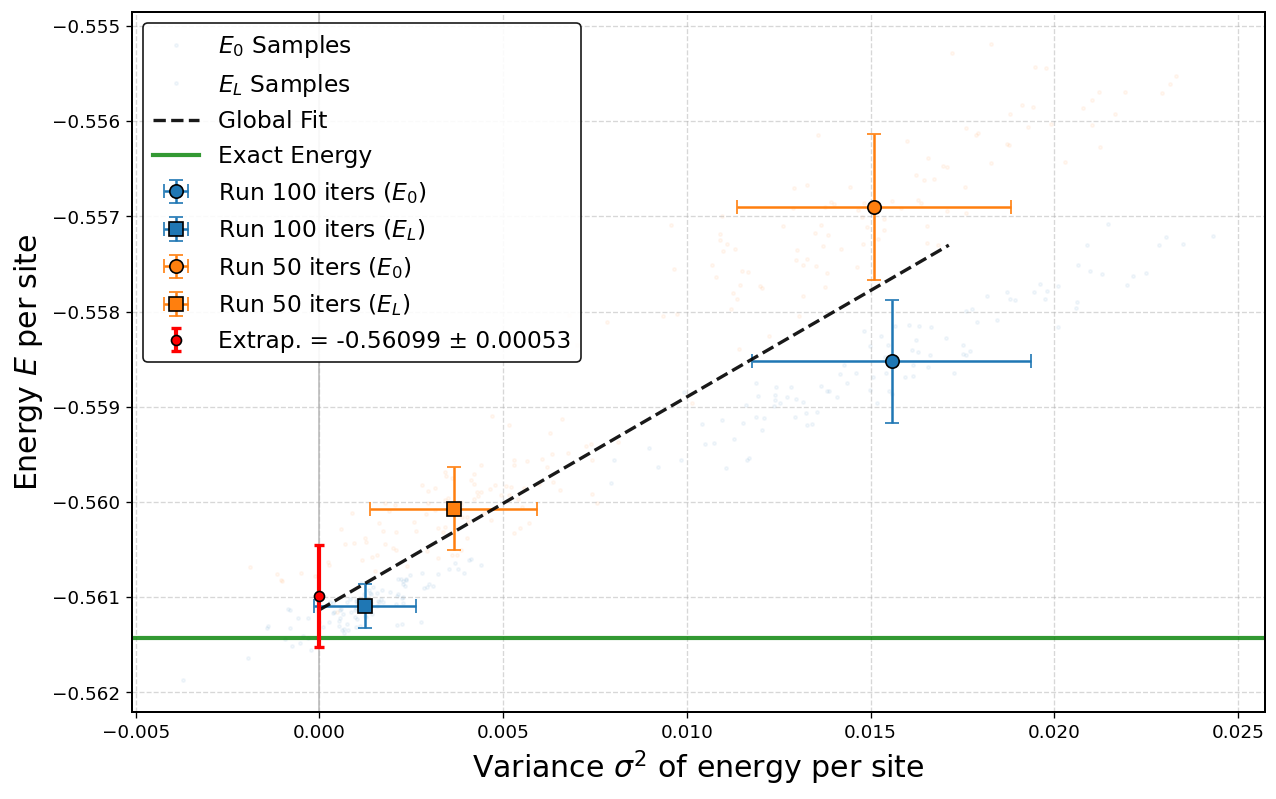

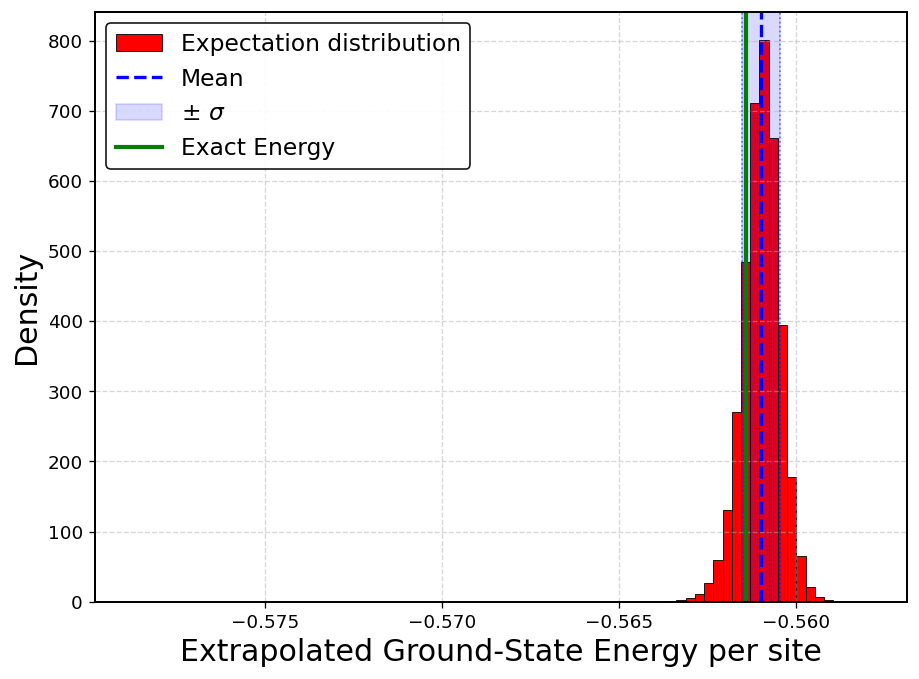

In [31]:
data_dict_AL = load_simulation_data(dossiers, L, verbose=True)
mc_results_AL = run_monte_carlo_extrapolation(data_dict_AL, N_sim, verbose=True)

plot_master_extrapolation(data_dict_AL, mc_results_AL, L, save_dir="../../assets/2D_4x4", name="AL_extrapolation")
plot_extrapolation_distribution(data_dict_AL, mc_results_AL, save_dir="../../assets/2D_4x4", name="AL_distribution")

In [32]:
df_results = create_results_table(data_dict_AL, L)
print(df_results.to_string(index=False))

 vmc_it  energy VMC  var VMC  sem VMC  energy lanczos  var lanczos  sem lanczos
     50   -0.556900 0.015093 0.001509       -0.560071     0.003659     0.000366
    100   -0.558522 0.015570 0.001557       -0.561089     0.001232     0.000123


## Krylov Subspace 

In [33]:
dossiers = glob.glob("../../datas/2D_4x4/datas_krylov_iter_*") 

Loading and processing 3 folders...
✅ Loading complete: 3 simulations processed!
Generating 1000000 synthetic linear regressions...

========== GLOBAL MONTE CARLO RESULTS ==========
Points used for fit       : 6 (3 simulations)
Exact Energy              : -0.56142416
Extrapolated Energy       : -0.56122857 ± 0.00089736
95% Confidence Interval   : [-0.56328792 , -0.55978654]
Absolute Error vs Exact   : 1.96e-04


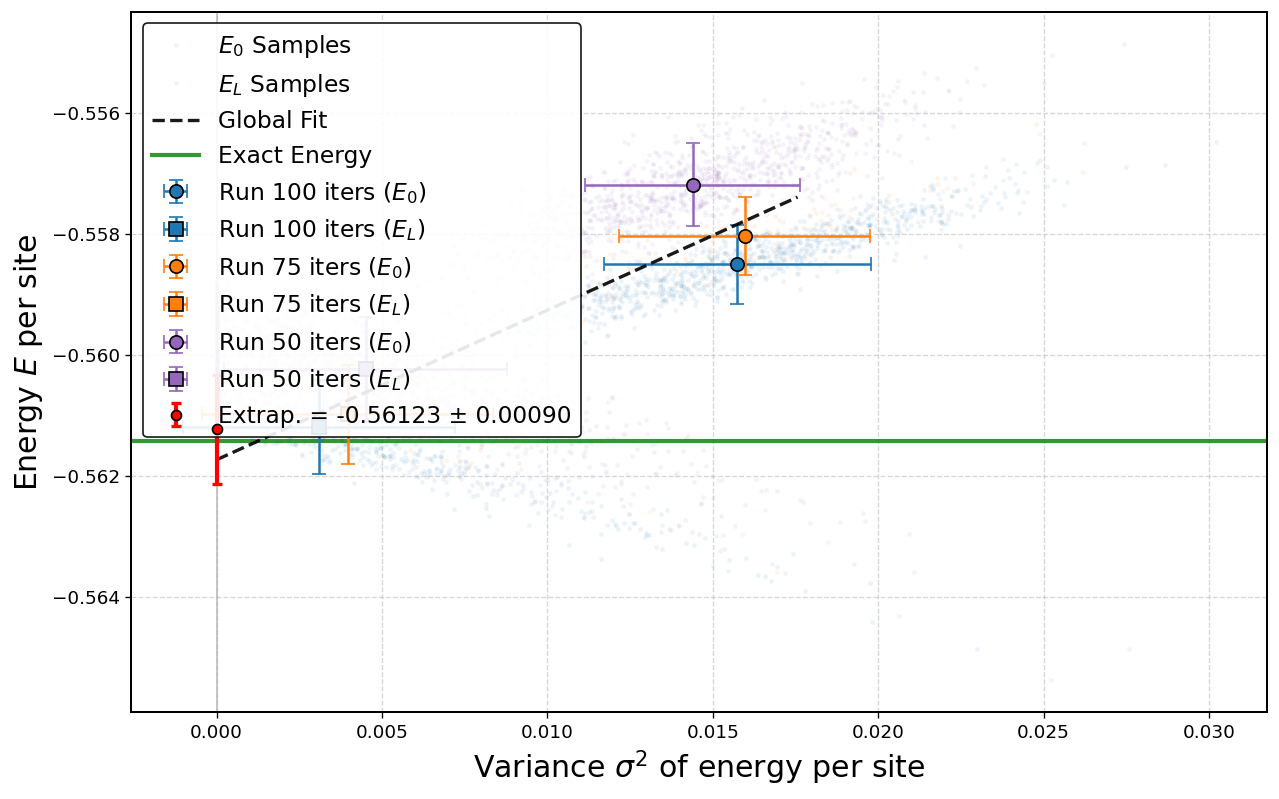

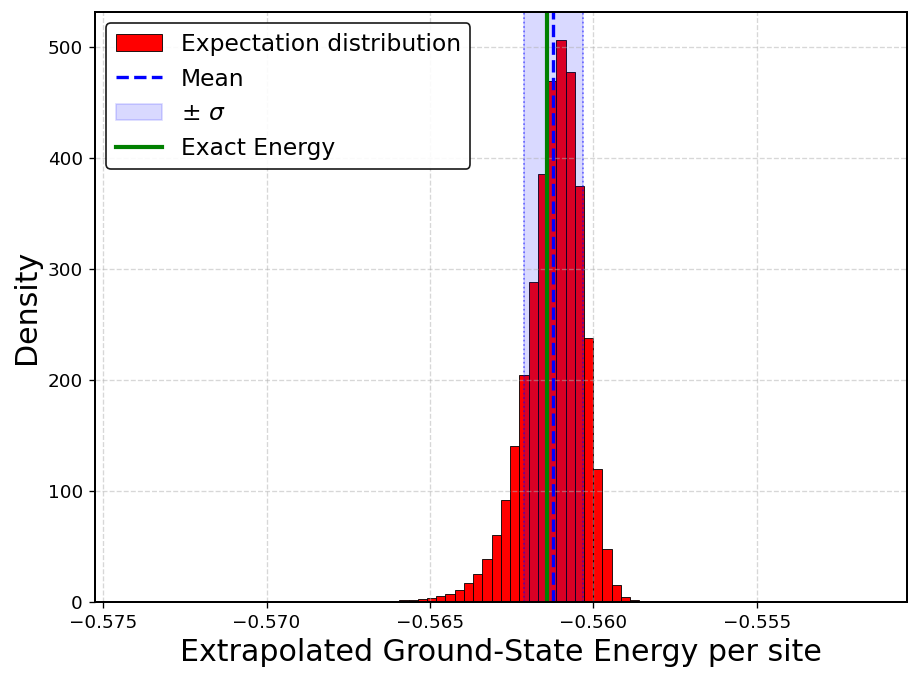

In [34]:
data_dict_KR = load_simulation_data(dossiers, L, verbose=True)
mc_results_KR = run_monte_carlo_extrapolation(data_dict_KR, N_sim, verbose=True)

plot_master_extrapolation(data_dict_KR, mc_results_KR, L, save_dir="../../assets/2D_4x4", name="Krylov_extrapolation")
plot_extrapolation_distribution(data_dict_KR, mc_results_KR, save_dir="../../assets/2D_4x4", name="Krylov_distribution")

In [35]:
df_results = create_results_table(data_dict_KR, L)
print(df_results.to_string(index=False))

 vmc_it  energy VMC  var VMC  sem VMC  energy lanczos  var lanczos  sem lanczos
     50   -0.557190 0.014399 0.000455       -0.560241     0.004514     0.000143
     75   -0.558034 0.015968 0.001597       -0.560985     0.003968     0.000397
    100   -0.558501 0.015739 0.000498       -0.561194     0.003105     0.000098


## Comparaison 

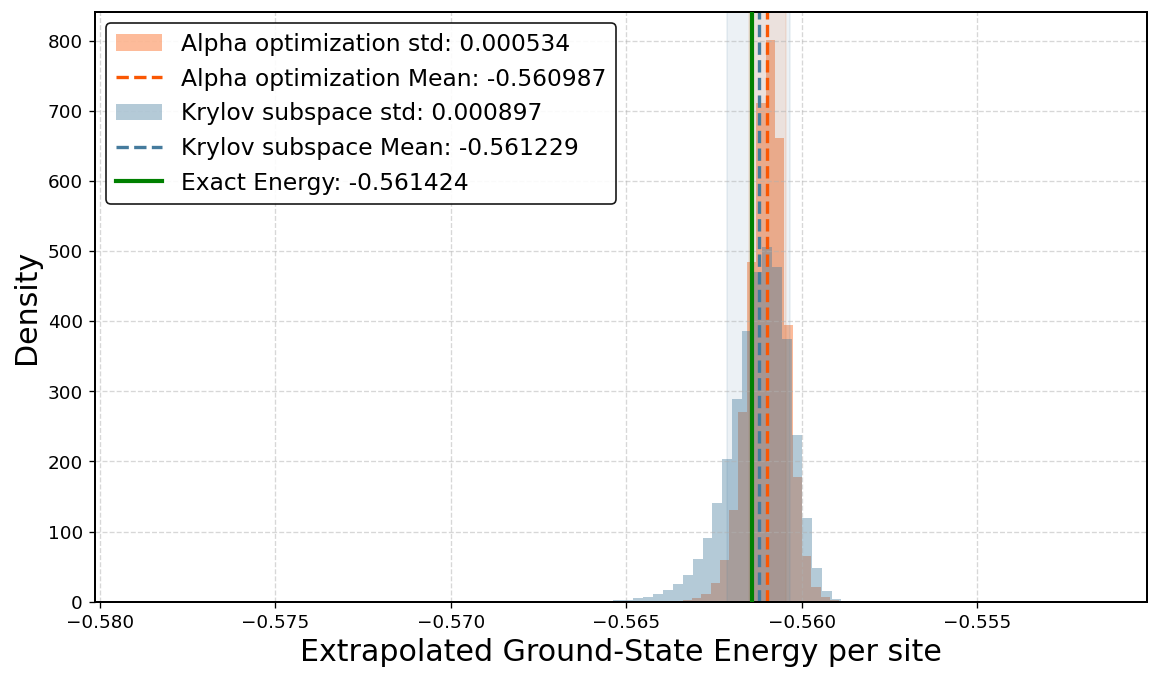

In [36]:
mes_distributions = {
    "Alpha optimization": mc_results_AL,
    "Krylov subspace": mc_results_KR
}

E_exacte = data_dict_AL["exact_gs_energy_per_site"]
plot_multiple_extrapolation_distributions(mes_distributions, E_exacte, save_dir="../../assets/2D_4x4")